### Importing libraries ###

In [ ]:
import sys, platform, struct
print(sys.version)
print(platform.platform(), platform.machine())
print(struct.calcsize('P')*8)
import pip
print(pip.__version__)

: 

In [ ]:
pip install --upgrade pip
pip install tensorflow


: 

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'tensorflow'

### Analyzing the dataset ###

In [ ]:
DATA_PATH="diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [8]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

In [63]:
target_counts = df['Diabetes_binary'].value_counts().sort_index()
target_percent = df['Diabetes_binary'].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent)

Target counts:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

Target percentages:
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


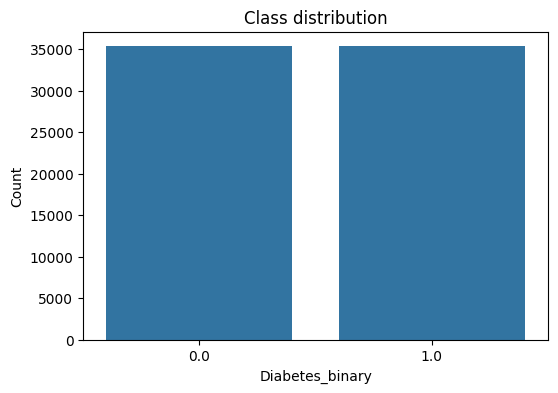

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes_binary', data=df)
plt.title("Class distribution")
plt.xlabel("Diabetes_binary")
plt.ylabel("Count")
plt.show()

In [65]:
if target_percent.max() <= 60:
    print("The dataset is balanced.")
else:
    print("The dataset is unbalanced.")

The dataset is balanced.


### Descriptive statistics ###

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


### Visualisations ###

In [1]:
AGE_LABELS = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80+",
}

In [ ]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

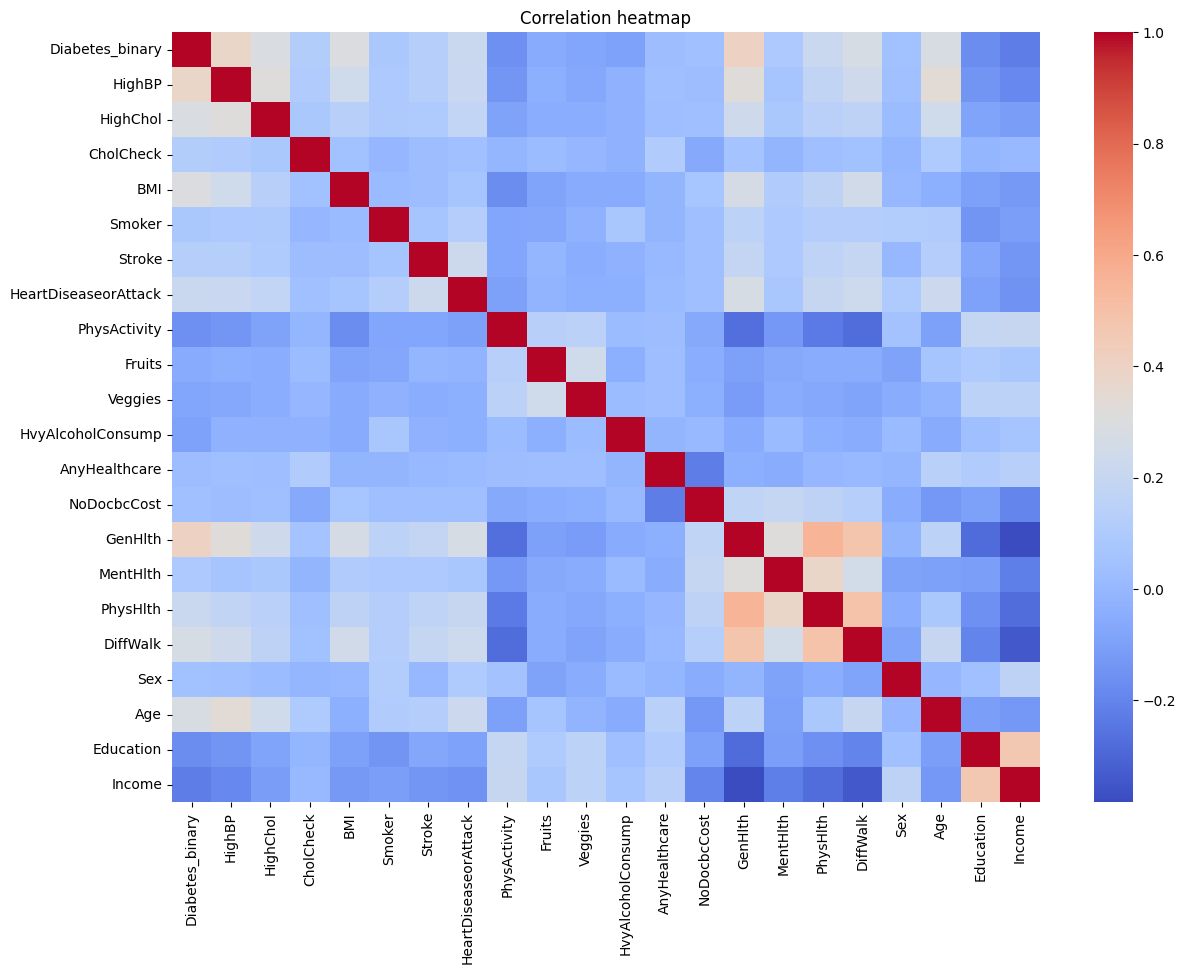

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation heatmap")
plt.show()

In [68]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70692, 21)
y shape: (70692,)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (56553, 21)
X_test : (14139, 21)
y_train: (56553,)
y_test : (14139,)


In [70]:
X_train_v1 = X_train.copy()
print(X_train_v1.var(axis=0))

HighBP                    0.246045
HighChol                  0.249353
CholCheck                 0.023874
BMI                      50.654943
Smoker                    0.249401
Stroke                    0.057765
HeartDiseaseorAttack      0.125627
PhysActivity              0.208936
Fruits                    0.237410
Veggies                   0.166914
HvyAlcoholConsump         0.040298
AnyHealthcare             0.043364
NoDocbcCost               0.084893
GenHlth                   1.238333
MentHlth                 65.996532
PhysHlth                100.438427
DiffWalk                  0.188452
Sex                       0.248151
Age                       8.132002
Education                 1.060809
Income                    4.726674
dtype: float64


In [71]:
norm = Normalizer().fit(X_train_v1)
norm_X_train = norm.transform(X_train_v1)

norm_X_train_df = pd.DataFrame(norm_X_train, columns=X_train.columns)
print(norm_X_train_df.var(axis=0))

HighBP                  0.000214
HighChol                0.000223
CholCheck               0.000061
BMI                     0.011501
Smoker                  0.000232
Stroke                  0.000045
HeartDiseaseorAttack    0.000099
PhysActivity            0.000226
Fruits                  0.000244
Veggies                 0.000184
HvyAlcoholConsump       0.000042
AnyHealthcare           0.000078
NoDocbcCost             0.000068
GenHlth                 0.000842
MentHlth                0.031558
PhysHlth                0.048211
DiffWalk                0.000128
Sex                     0.000237
Age                     0.009924
Education               0.002226
Income                  0.006349
dtype: float64


In [72]:
selector = VarianceThreshold(threshold=1e-4)
selected_features_var = selector.fit_transform(norm_X_train)

selected_columns_var = X_train.columns[selector.get_support()]
print("Selected columns with VarianceThreshold:")
print(selected_columns_var.tolist())
print("Number of selected features:", len(selected_columns_var))

Selected columns with VarianceThreshold:
['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Number of selected features: 15


In [74]:
dt = DecisionTreeClassifier(random_state=500)

dt.fit(X_train, y_train)
preds_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, preds_dt)
dt_f1 = f1_score(y_test, preds_dt)

print("Decision Tree - All Features")
print("Accuracy:", dt_acc)
print("F1-score:", dt_f1)

Decision Tree - All Features
Accuracy: 0.6542188273569559
F1-score: 0.6508605298864529


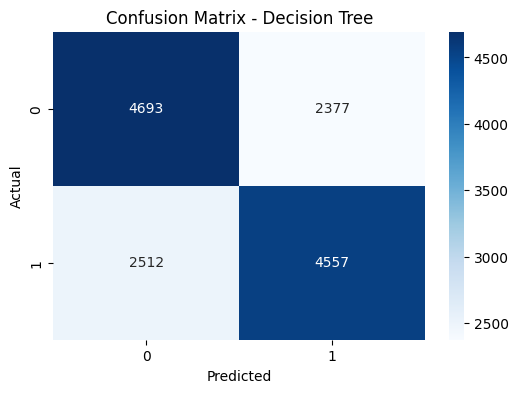

In [77]:
cm_dt = confusion_matrix(y_test, preds_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [78]:
print(classification_report(y_test, preds_dt))

              precision    recall  f1-score   support

         0.0       0.65      0.66      0.66      7070
         1.0       0.66      0.64      0.65      7069

    accuracy                           0.65     14139
   macro avg       0.65      0.65      0.65     14139
weighted avg       0.65      0.65      0.65     14139



In [75]:
X_train_var = X_train[selected_columns_var]
X_test_var = X_test[selected_columns_var]

dt.fit(X_train_var, y_train)
preds_dt_var = dt.predict(X_test_var)

dt_var_acc = accuracy_score(y_test, preds_dt_var)
dt_var_f1 = f1_score(y_test, preds_dt_var)

print("Decision Tree with VarianceThreshold features")
print("Accuracy:", round(dt_var_acc, 4))
print("F1-score:", round(dt_var_f1, 4))

Decision Tree with VarianceThreshold features
Accuracy: 0.6583
F1-score: 0.6542


In [79]:
X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()

f1_score_list = []

for k in range(1, X_train.shape[1] + 1):
    selector_k = SelectKBest(score_func=chi2, k=k)
    selector_k.fit(X_train_v2, y_train)

    sel_X_train_v2 = selector_k.transform(X_train_v2)
    sel_X_test_v2 = selector_k.transform(X_test_v2)

    dt.fit(sel_X_train_v2, y_train)
    kbest_preds = dt.predict(sel_X_test_v2)

    f1_k = round(f1_score(y_test, kbest_preds), 4)
    f1_score_list.append(f1_k)

print(f1_score_list)

[0.5207, 0.6555, 0.6253, 0.6675, 0.6758, 0.6813, 0.6685, 0.6505, 0.652, 0.6533, 0.6514, 0.6558, 0.6502, 0.6484, 0.6493, 0.6467, 0.6506, 0.6477, 0.6489, 0.6507, 0.6509]


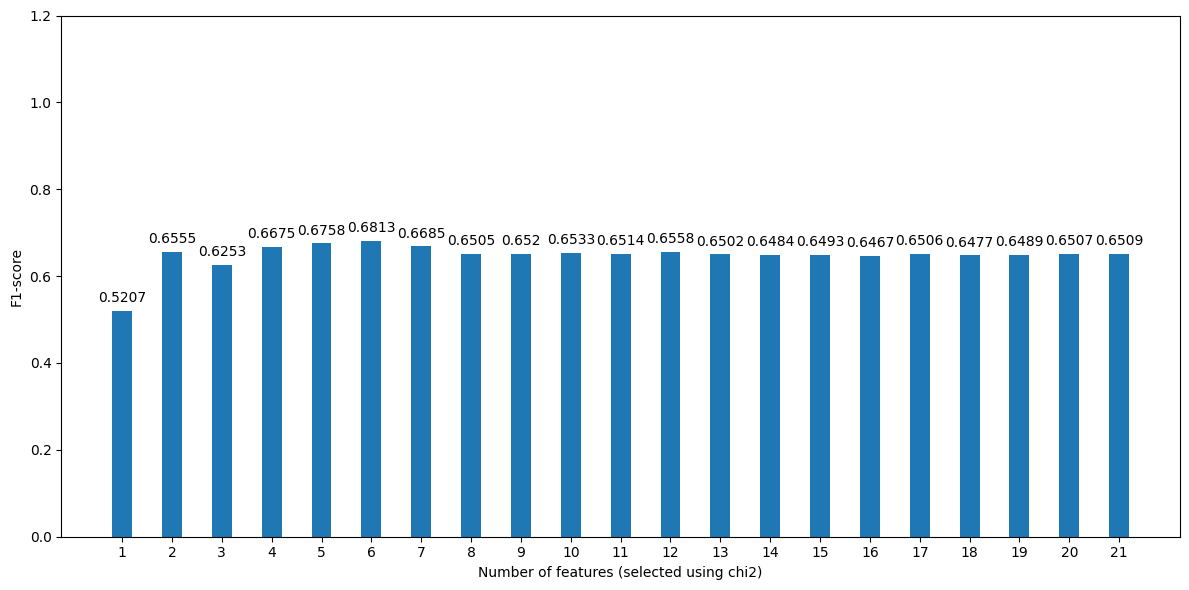

In [80]:
fig, ax = plt.subplots(figsize=(12, 6))
x_vals = [str(i) for i in range(1, X_train.shape[1] + 1)]
y_vals = f1_score_list

ax.bar(x_vals, y_vals, width=0.4)
ax.set_xlabel('Number of features (selected using chi2)')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.2)

for index, value in enumerate(y_vals):
    plt.text(x=index, y=value + 0.02, s=str(value), ha='center')

plt.tight_layout()
plt.show()

In [81]:
best_k = np.argmax(f1_score_list) + 1
print("Best k:", best_k)
print("Best F1-score:", max(f1_score_list))

Best k: 6
Best F1-score: 0.6813


In [82]:
selector_best = SelectKBest(score_func=chi2, k=best_k)
selector_best.fit(X_train, y_train)

selected_columns_kbest = X_train.columns[selector_best.get_support()]
print(selected_columns_kbest.tolist())

['HighBP', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']


In [83]:
X_train_kbest = selector_best.transform(X_train)
X_test_kbest = selector_best.transform(X_test)

dt.fit(X_train_kbest, y_train)
preds_dt_kbest = dt.predict(X_test_kbest)

dt_kbest_acc = round(accuracy_score(y_test, preds_dt_kbest), 4)
dt_kbest_f1 = round(f1_score(y_test, preds_dt_kbest), 4)

print("Decision Tree - SelectKBest")
print("Accuracy:", dt_kbest_acc)
print("F1-score:", dt_kbest_f1)

Decision Tree - SelectKBest
Accuracy: 0.6855
F1-score: 0.6813


In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(56553, 21)
(14139, 21)


In [85]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

preds_lr = lr.predict(X_test_scaled)

lr_acc = round(accuracy_score(y_test, preds_lr), 4)
lr_f1 = round(f1_score(y_test, preds_lr), 4)

print("Logistic Regression")
print("Accuracy:", lr_acc)
print("F1-score:", lr_f1)

Logistic Regression
Accuracy: 0.7458
F1-score: 0.7503


[[5145 1925]
 [1669 5400]]


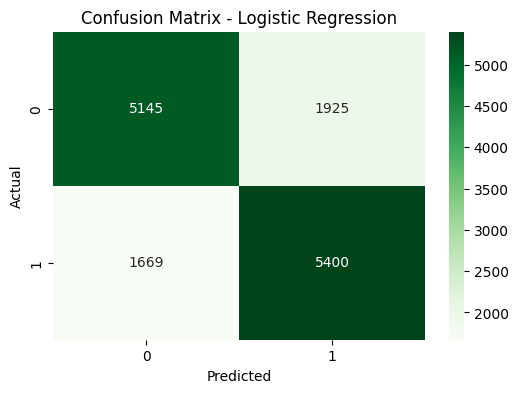

In [86]:
cm_lr = confusion_matrix(y_test, preds_lr)
print(cm_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [87]:
print(classification_report(y_test, preds_lr))

              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [88]:
ns_probs = [0 for _ in range(len(y_test))]
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

print('No Skill: ROC AUC = %.4f' % ns_auc)
print('Logistic Regression: ROC AUC = %.4f' % lr_auc)

No Skill: ROC AUC = 0.5000
Logistic Regression: ROC AUC = 0.8232


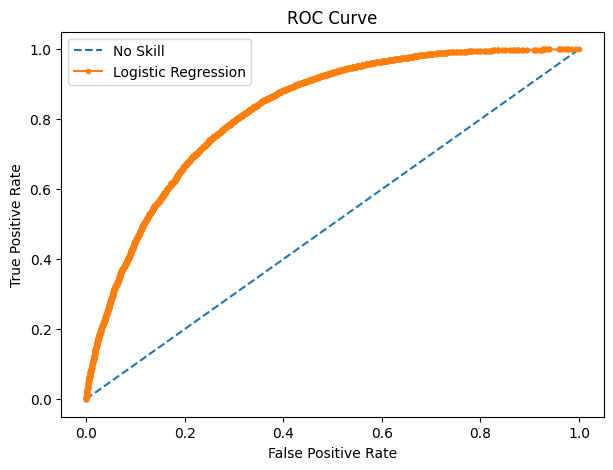

In [89]:
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

plt.figure(figsize=(7,5))
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### CNN Model ###

In [90]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

CNN train shape: (56553, 21, 1)
CNN test shape: (14139, 21, 1)


In [91]:
cnn_model = Sequential()

cnn_model.add(Input(shape=(X_train_cnn.shape[1], 1)))
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 19, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 8, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [93]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [94]:
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7243 - loss: 0.5475 - val_accuracy: 0.7446 - val_loss: 0.5126
Epoch 2/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7398 - loss: 0.5258 - val_accuracy: 0.7476 - val_loss: 0.5086
Epoch 3/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7422 - loss: 0.5224 - val_accuracy: 0.7525 - val_loss: 0.5053
Epoch 4/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7431 - loss: 0.5191 - val_accuracy: 0.7507 - val_loss: 0.5067
Epoch 5/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7438 - loss: 0.5185 - val_accuracy: 0.7476 - val_loss: 0.5071
Epoch 6/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7457 - loss: 0.5169 - val_accuracy: 0.7512 - val_loss: 0.5046
Epoch 7/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7459 - loss: 0.5169 - val_accuracy: 0.7507 - val_loss: 0.5067
Epoch 8/100
707/707 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7481 - loss: 0.5151 - val_accu

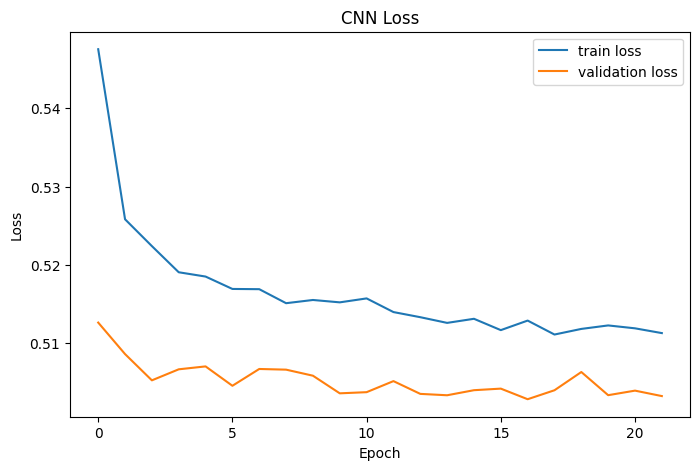

In [95]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

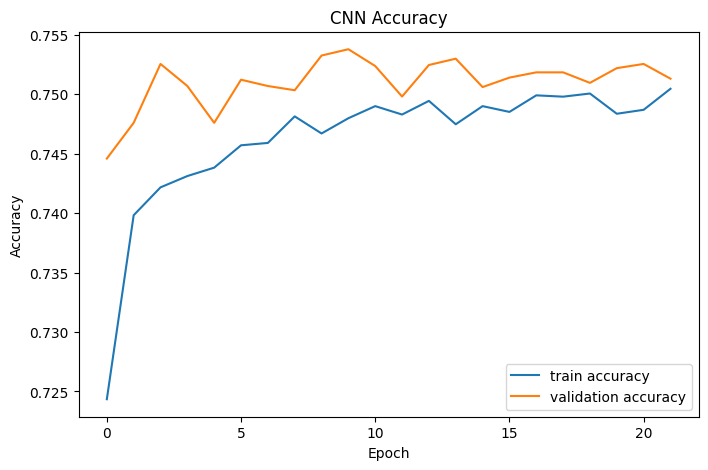

In [96]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [97]:
cnn_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=1)
print("CNN Test loss:", cnn_loss)
print("CNN Test accuracy:", cnn_test_acc)

442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.7473 - loss: 0.5072
CNN Test loss: 0.5071635246276855
CNN Test accuracy: 0.7472947239875793


In [98]:
cnn_probs = cnn_model.predict(X_test_cnn)
cnn_preds = (cnn_probs > 0.5).astype(int)

cnn_acc = round(accuracy_score(y_test, cnn_preds), 4)
cnn_f1 = round(f1_score(y_test, cnn_preds), 4)
cnn_auc = round(roc_auc_score(y_test, cnn_probs), 4)

print("CNN Accuracy:", cnn_acc)
print("CNN F1-score:", cnn_f1)
print("CNN ROC AUC:", cnn_auc)

442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step
CNN Accuracy: 0.7473
CNN F1-score: 0.7603
CNN ROC AUC: 0.8264


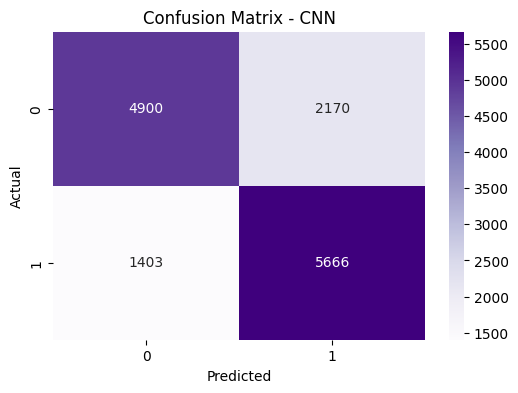

              precision    recall  f1-score   support

         0.0       0.78      0.69      0.73      7070
         1.0       0.72      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [99]:
cm_cnn = confusion_matrix(y_test, cnn_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, cnn_preds))

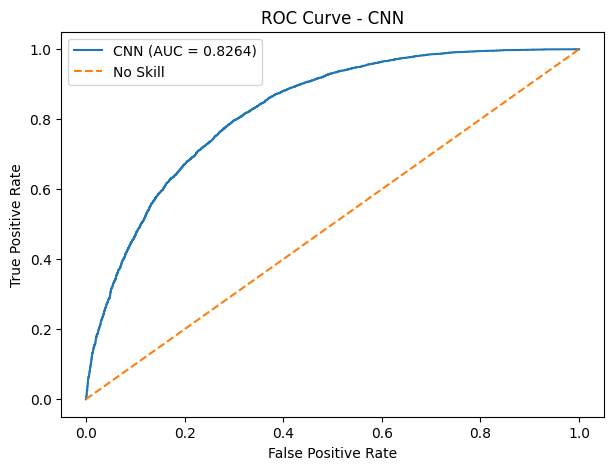

In [100]:
cnn_fpr, cnn_tpr, _ = roc_curve(y_test, cnn_probs)

plt.figure(figsize=(7,5))
plt.plot(cnn_fpr, cnn_tpr, label=f'CNN (AUC = {cnn_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN")
plt.legend()
plt.show()

### Fine Tuning ###

In [101]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV score:", grid_lr.best_score_)

Best LR params: {'C': 1, 'solver': 'lbfgs'}
Best LR CV score: 0.7538037364867772


In [102]:
best_lr = grid_lr.best_estimator_
preds_best_lr = best_lr.predict(X_test_scaled)

best_lr_acc = round(accuracy_score(y_test, preds_best_lr), 4)
best_lr_f1 = round(f1_score(y_test, preds_best_lr), 4)

print("Tuned Logistic Regression")
print("Accuracy:", best_lr_acc)
print("F1-score:", best_lr_f1)
print(confusion_matrix(y_test, preds_best_lr))
print(classification_report(y_test, preds_best_lr))

Tuned Logistic Regression
Accuracy: 0.7458
F1-score: 0.7503
[[5145 1925]
 [1669 5400]]
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [103]:
best_lr_probs = best_lr.predict_proba(X_test_scaled)[:, 1]
best_lr_auc = roc_auc_score(y_test, best_lr_probs)

print("Tuned Logistic Regression ROC AUC:", round(best_lr_auc, 4))

Tuned Logistic Regression ROC AUC: 0.8232


In [104]:
thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results = []

for t in thresholds:
    preds_t = (best_lr_probs > t).astype(int)
    f1_t = f1_score(y_test, preds_t)
    threshold_results.append((t, round(f1_t, 4)))

threshold_results

[(np.float64(0.3), 0.7694),
 (np.float64(0.35), 0.7719),
 (np.float64(0.39999999999999997), 0.7709),
 (np.float64(0.44999999999999996), 0.7628),
 (np.float64(0.49999999999999994), 0.7503),
 (np.float64(0.5499999999999999), 0.7336),
 (np.float64(0.5999999999999999), 0.7072),
 (np.float64(0.6499999999999999), 0.67),
 (np.float64(0.7), 0.6232)]

In [105]:
best_threshold, best_threshold_f1 = max(threshold_results, key=lambda x: x[1])
print("Best threshold:", best_threshold)
print("Best threshold F1:", best_threshold_f1)

Best threshold: 0.35
Best threshold F1: 0.7719


In [106]:
def build_cnn_model(input_shape, filters1=32, filters2=64, kernel_size1=3, kernel_size2=2,
                    dropout_rate=0.2, dense_units=32, learning_rate=0.001):
    model = Sequential()
    
    model.add(Input(shape=input_shape))
    model.add(Conv1D(filters=filters1, kernel_size=kernel_size1, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))
    
    model.add(Conv1D(filters=filters2, kernel_size=kernel_size2, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))
    
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [107]:
cnn_configs = [
    {'filters1': 32, 'filters2': 64, 'kernel_size1': 3, 'kernel_size2': 2, 'dropout_rate': 0.2, 'dense_units': 32, 'learning_rate': 0.001, 'batch_size': 64},
    {'filters1': 32, 'filters2': 64, 'kernel_size1': 3, 'kernel_size2': 2, 'dropout_rate': 0.3, 'dense_units': 64, 'learning_rate': 0.001, 'batch_size': 64},
    {'filters1': 64, 'filters2': 128, 'kernel_size1': 3, 'kernel_size2': 2, 'dropout_rate': 0.3, 'dense_units': 64, 'learning_rate': 0.001, 'batch_size': 64},
    {'filters1': 32, 'filters2': 64, 'kernel_size1': 2, 'kernel_size2': 2, 'dropout_rate': 0.2, 'dense_units': 64, 'learning_rate': 0.0005, 'batch_size': 128},
]

In [109]:
cnn_tuning_results = []

for i, config in enumerate(cnn_configs):
    print(f"Training configuration {i+1}/{len(cnn_configs)}")
    print(config)
    
    model_tuned = build_cnn_model(
        input_shape=(X_train_cnn.shape[1], 1),
        filters1=config['filters1'],
        filters2=config['filters2'],
        kernel_size1=config['kernel_size1'],
        kernel_size2=config['kernel_size2'],
        dropout_rate=config['dropout_rate'],
        dense_units=config['dense_units'],
        learning_rate=config['learning_rate']
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    history_tuned = model_tuned.fit(
        X_train_cnn, y_train,
        epochs=100,
        batch_size=config['batch_size'],
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_prob_tuned = model_tuned.predict(X_test_cnn, verbose=0)
    y_pred_tuned = (y_prob_tuned > 0.5).astype(int)
    
    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    auc_tuned = roc_auc_score(y_test, y_prob_tuned)
    
    cnn_tuning_results.append({
        'config_id': i + 1,
        'filters1': config['filters1'],
        'filters2': config['filters2'],
        'kernel_size1': config['kernel_size1'],
        'kernel_size2': config['kernel_size2'],
        'dropout_rate': config['dropout_rate'],
        'dense_units': config['dense_units'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'accuracy': round(acc_tuned, 4),
        'f1_score': round(f1_tuned, 4),
        'roc_auc': round(auc_tuned, 4)
    })

Training configuration 1/4
{'filters1': 32, 'filters2': 64, 'kernel_size1': 3, 'kernel_size2': 2, 'dropout_rate': 0.2, 'dense_units': 32, 'learning_rate': 0.001, 'batch_size': 64}
Training configuration 2/4
{'filters1': 32, 'filters2': 64, 'kernel_size1': 3, 'kernel_size2': 2, 'dropout_rate': 0.3, 'dense_units': 64, 'learning_rate': 0.001, 'batch_size': 64}
Training configuration 3/4
{'filters1': 64, 'filters2': 128, 'kernel_size1': 3, 'kernel_size2': 2, 'dropout_rate': 0.3, 'dense_units': 64, 'learning_rate': 0.001, 'batch_size': 64}
Training configuration 4/4
{'filters1': 32, 'filters2': 64, 'kernel_size1': 2, 'kernel_size2': 2, 'dropout_rate': 0.2, 'dense_units': 64, 'learning_rate': 0.0005, 'batch_size': 128}


In [110]:
cnn_tuning_df = pd.DataFrame(cnn_tuning_results)
cnn_tuning_df.sort_values(by='f1_score', ascending=False)

,config_id,filters1,filters2,kernel_size1,kernel_size2,dropout_rate,dense_units,learning_rate,batch_size,accuracy,f1_score,roc_auc
3,4,32,64,2,2,0.2,64,0.0005,128,0.7452,0.7611,0.8241
0,1,32,64,3,2,0.2,32,0.0010,64,0.7481,0.7586,0.8258
1,2,32,64,3,2,0.3,64,0.0010,64,0.7469,0.7581,0.8256
2,3,64,128,3,2,0.3,64,0.0010,64,0.7456,0.7568,0.8252


In [111]:
best_cnn_row = cnn_tuning_df.sort_values(by='f1_score', ascending=False).iloc[0]
print("Best CNN configuration:")
print(best_cnn_row)

Best CNN configuration:
config_id          4.0000
filters1          32.0000
filters2          64.0000
kernel_size1       2.0000
kernel_size2       2.0000
dropout_rate       0.2000
dense_units       64.0000
learning_rate      0.0005
batch_size       128.0000
accuracy           0.7452
f1_score           0.7611
roc_auc            0.8241
Name: 3, dtype: float64


In [112]:
best_config = cnn_configs[int(best_cnn_row['config_id']) - 1]

best_cnn_model = build_cnn_model(
    input_shape=(X_train_cnn.shape[1], 1),
    filters1=best_config['filters1'],
    filters2=best_config['filters2'],
    kernel_size1=best_config['kernel_size1'],
    kernel_size2=best_config['kernel_size2'],
    dropout_rate=best_config['dropout_rate'],
    dense_units=best_config['dense_units'],
    learning_rate=best_config['learning_rate']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

best_cnn_history = best_cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=best_config['batch_size'],
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7133 - loss: 0.5595 - val_accuracy: 0.7421 - val_loss: 0.5177
Epoch 2/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7370 - loss: 0.5295 - val_accuracy: 0.7471 - val_loss: 0.5122
Epoch 3/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7391 - loss: 0.5245 - val_accuracy: 0.7464 - val_loss: 0.5122
Epoch 4/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7425 - loss: 0.5210 - val_accuracy: 0.7507 - val_loss: 0.5081
Epoch 5/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7441 - loss: 0.5188 - val_accuracy: 0.7502 - val_loss: 0.5069
Epoch 6/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7464 - loss: 0.5178 - val_accuracy: 0.7494 - val_loss: 0.5067
Epoch 7/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7462 - loss: 0.5159 - val_accuracy: 0.7497 - val_loss: 0.5069
Epoch 8/100
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7464 - loss: 0.5164 - val_accu

In [113]:
best_cnn_probs = best_cnn_model.predict(X_test_cnn, verbose=0)
best_cnn_preds = (best_cnn_probs > 0.5).astype(int)

best_cnn_acc = round(accuracy_score(y_test, best_cnn_preds), 4)
best_cnn_f1 = round(f1_score(y_test, best_cnn_preds), 4)
best_cnn_auc = round(roc_auc_score(y_test, best_cnn_probs), 4)

print("Tuned CNN Accuracy:", best_cnn_acc)
print("Tuned CNN F1-score:", best_cnn_f1)
print("Tuned CNN ROC AUC:", best_cnn_auc)

Tuned CNN Accuracy: 0.7498
Tuned CNN F1-score: 0.7617
Tuned CNN ROC AUC: 0.8264


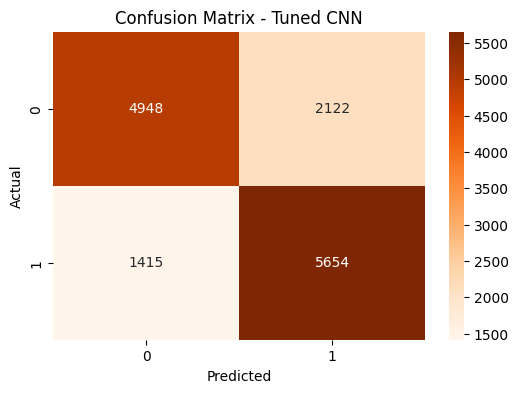

In [114]:
cm_best_cnn = confusion_matrix(y_test, best_cnn_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_best_cnn, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Tuned CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [115]:
print(classification_report(y_test, best_cnn_preds))

              precision    recall  f1-score   support

         0.0       0.78      0.70      0.74      7070
         1.0       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



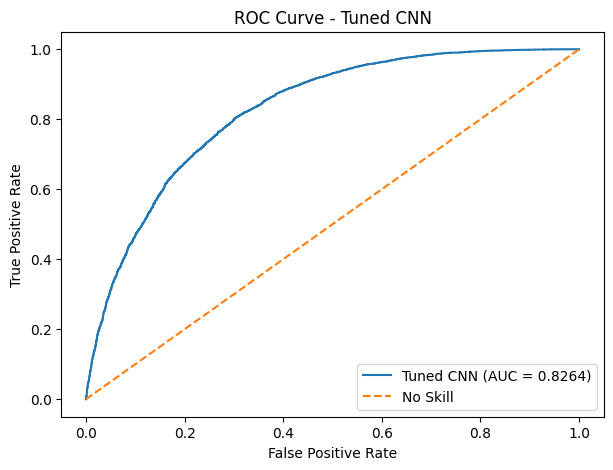

In [116]:
best_cnn_fpr, best_cnn_tpr, _ = roc_curve(y_test, best_cnn_probs)

plt.figure(figsize=(7,5))
plt.plot(best_cnn_fpr, best_cnn_tpr, label=f'Tuned CNN (AUC = {best_cnn_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned CNN")
plt.legend()
plt.show()

In [117]:
cnn_compare = pd.DataFrame({
    'Model': ['Baseline CNN', 'Tuned CNN'],
    'Accuracy': [cnn_acc, best_cnn_acc],
    'F1-score': [cnn_f1, best_cnn_f1],
    'ROC AUC': [cnn_auc, best_cnn_auc]
})

cnn_compare

,Model,Accuracy,F1-score,ROC AUC
0,Baseline CNN,0.7473,0.7603,0.8264
1,Tuned CNN,0.7498,0.7617,0.8264


In [118]:
results = pd.DataFrame({
    'Model': [
        'Decision Tree - all features',
        'Decision Tree - VarianceThreshold',
        'Decision Tree - SelectKBest',
        'Logistic Regression',
        'Tuned Logistic Regression',
        'Baseline CNN',
        'Tuned CNN'
    ],
    'Accuracy': [
        dt_acc,
        dt_var_acc,
        dt_kbest_acc,
        lr_acc,
        best_lr_acc,
        cnn_acc,
        best_cnn_acc
    ],
    'F1-score': [
        dt_f1,
        dt_var_f1,
        dt_kbest_f1,
        lr_f1,
        best_lr_f1,
        cnn_f1,
        best_cnn_f1
    ]
})

results.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,F1-score
6,Tuned CNN,0.749800,0.761700
5,Baseline CNN,0.747300,0.760300
3,Logistic Regression,0.745800,0.750300
4,Tuned Logistic Regression,0.745800,0.750300
2,Decision Tree - SelectKBest,0.685500,0.681300
1,Decision Tree - VarianceThreshold,0.658321,0.654163
0,Decision Tree - all features,0.654219,0.650861


In [119]:
best_model_row = results.sort_values(by='F1-score', ascending=False).iloc[0]
print("Best final model based on F1-score:")
print(best_model_row)

Best final model based on F1-score:
Model       Tuned CNN
Accuracy       0.7498
F1-score       0.7617
Name: 6, dtype: object
